In [206]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [207]:
df = pd.read_csv("tokyo_weather.csv")

df["Date"] = pd.to_datetime(df["Date"])


df = df.set_index("Date")

# Column we want to predict
TARGET = "Highest Temperature (°C)"

# Convert all columns to numeric values
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")


df.head()



,Average Temperature (°C),Highest Temperature (°C),Highest Temperature (°C) Datetime,Lowest Temperature (°C),Lowest Temperature (°C) Datetime,Total Precipitation (mm),Sunshine Duration (hours),Maximum Snow Depth (cm),Maximum Snow Depth (cm) Datetime,Total Snowfall (cm),...,Maximum Wind Speed (m/s) Datetime,Maximum Wind Speed (m/s) Direction,Maximum Gust Speed (m/s),Maximum Gust Speed (m/s) Datetime,Maximum Gust Speed (m/s) Direction,Most Frequent Wind Direction (16-point compass),Average Vapor Pressure (hPa),Average Humidity (%),Minimum Relative Humidity (%),Minimum Relative Humidity (%) Datetime
Date,,,,,,,,,,,,,,,,,,,,,
2018-06-26,25.7,30.1,NaN,22.3,NaN,0.0,9.2,0,NaN,0,...,NaN,NaN,12.4,NaN,NaN,NaN,24.7,75,56,NaN
2018-06-27,27.7,31.7,NaN,24.9,NaN,0.0,7.6,0,NaN,0,...,NaN,NaN,20.0,NaN,NaN,NaN,26.1,71,57,NaN
2018-06-28,27.4,31.9,NaN,25.2,NaN,0.0,4.8,0,NaN,0,...,NaN,NaN,16.1,NaN,NaN,NaN,27.9,77,60,NaN
2018-06-29,28.2,32.9,NaN,25.4,NaN,0.0,12.8,0,NaN,0,...,NaN,NaN,16.9,NaN,NaN,NaN,27.7,73,55,NaN
2018-06-30,28.6,32.7,NaN,25.2,NaN,0.0,13.1,0,NaN,0,...,NaN,NaN,15.5,NaN,NaN,NaN,28.5,74,57,NaN


In [ ]:

def create_features(data):
    """
    Create date-based features from the Date index.
    These help the model learn seasonal patterns.
    """
    data = data.copy()

    data["dayofweek"] = data.index.dayofweek
    data["month"] = data.index.month
    data["dayofyear"] = data.index.dayofyear
    data["dayofmonth"] = data.index.day
    data["weekofyear"] = data.index.isocalendar().week.astype(int)
    
    ##test features

    


    return data


def add_lags(data):
    """
    Create lag features.
    These tell the model what the temperature was on previous days.
    """
    data = data.copy()

    data["lag1_day"] = data[TARGET].shift(1)
    data["lag2_day"] = data[TARGET].shift(2)
    data["lag3_day"] = data[TARGET].shift(3)
    data["lag7_day"] = data[TARGET].shift(7)

    #test
    data["rolling_7"] = data[TARGET].shift(1).rolling(7).mean()
    data["rolling_3"] = data[TARGET].shift(1).rolling(3).mean()
    data["rolling_2"] = data[TARGET].shift(1).rolling(2).mean()
    
    data["diff_from_avg_7"] = data[TARGET].shift(1) - data["rolling_7"]

    return data


df = create_features(df)
df = add_lags(df)

# Remove rows where lag values are missing
needed_cols = [TARGET, "lag1_day", "lag2_day", "lag3_day", "lag7_day"]
df = df.dropna(subset=needed_cols)



In [209]:
# Use every column except the target as input features for training
FEATURES = [col for col in df.columns if col != TARGET]

X = df[FEATURES]
y = df[TARGET]

In [210]:
# Time series cross-validation

# Number of time-series validation folds
n_splits = 5

# Use up to 15 days for each validation fold
test_size = min(15, len(df) // (n_splits + 1))

tss = TimeSeriesSplit(n_splits=n_splits, test_size=test_size)

mae_scores = []
rmse_scores = []
mape_scores = []

for fold, (train_idx, val_idx) in enumerate(tss.split(df), start=1):

    train = df.iloc[train_idx]
    test = df.iloc[val_idx]

    X_train = train[FEATURES]
    y_train = train[TARGET]

    X_test = test[FEATURES]
    y_test = test[TARGET]

  
    model = xgb.XGBRegressor(
        n_estimators=500,
        learning_rate=0.03,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42
    )

    # Train model
    model.fit(X_train, y_train)

    # Predict validation values
    preds = model.predict(X_test)

    # Calculate errors
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))

    # Calculate MAPE
    ape = np.abs((y_test.values - preds) / y_test.values)
    ape = ape[np.isfinite(ape)]
    mape = np.mean(ape) * 100

    mae_scores.append(mae)
    rmse_scores.append(rmse)
    mape_scores.append(mape)

    print(f"Fold {fold}")
    print("MAE:", mae)
    print("RMSE:", rmse)
    print("MAPE:", mape, "%")
    print("-" * 30)



print("Average CV MAE:", np.mean(mae_scores))
print("Average CV RMSE:", np.mean(rmse_scores))
print("Average CV MAPE:", np.mean(mape_scores), "%")


# --------------------------------------------------
# Final last-15-days test
# --------------------------------------------------

# Use the last 15 days as final test set
final_test_size = min(15, len(df) // 5)

train_df = df.iloc[:-final_test_size]
test_df = df.iloc[-final_test_size:]

X_train = train_df[FEATURES]
y_train = train_df[TARGET]

X_test = test_df[FEATURES]
y_test = test_df[TARGET]

# Train final model
final_model = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42
)

final_model.fit(X_train, y_train)

# Predict final test set
final_preds = final_model.predict(X_test)


Fold 1
MAE: 0.3197046661376959
RMSE: 0.3925441137020747
MAPE: 1.3701102936901224 %
------------------------------
Fold 2
MAE: 0.46039093017578075
RMSE: 0.49601925050972134
MAPE: 1.9151845027023175 %
------------------------------
Fold 3
MAE: 0.33567710876464835
RMSE: 0.459359811189382
MAPE: 1.4050849421615321 %
------------------------------
Fold 4
MAE: 0.46792910257975273
RMSE: 0.5377333157183759
MAPE: 1.8257955423278447 %
------------------------------
Fold 5
MAE: 0.5634318542480469
RMSE: 0.7082297539851287
MAPE: 2.0685907380810735 %
------------------------------
Average CV MAE: 0.4294267323811849
Average CV RMSE: 0.5187772490209366
Average CV MAPE: 1.716953203792578 %


,Date,Actual,Predicted,Error,Absolute Error,APE,APE (%)
0,2024-06-12,30.1,30.127762,-0.027762,0.027762,0.000922,0.092232
1,2024-06-13,25.4,26.408125,-1.008125,1.008125,0.039690,3.968996
2,2024-06-14,31.7,31.627518,0.072482,0.072482,0.002287,0.228651
3,2024-06-15,29.9,30.143776,-0.243776,0.243776,0.008153,0.815304
4,2024-06-16,28.7,29.092932,-0.392932,0.392932,0.013691,1.369100
5,2024-06-17,30.5,30.940445,-0.440445,0.440445,0.014441,1.444082
6,2024-06-18,22.5,21.186520,1.313480,1.313480,0.058377,5.837691
7,2024-06-19,29.5,29.209339,0.290661,0.290661,0.009853,0.985291
8,2024-06-20,28.4,28.660990,-0.260990,0.260990,0.009190,0.918978
9,2024-06-21,23.3,22.715969,0.584031,0.584031,0.025066,2.506570


Final MAE: 0.5634318542480469
Final RMSE: 0.7082297539851287
Final MAPE: 2.0685907380810735 %


,Feature,Importance
0,Average Temperature (°C),0.728510
2,Lowest Temperature (°C),0.117859
17,Average Vapor Pressure (hPa),0.041366
30,rolling_7,0.027367
5,Sunshine Duration (hours),0.019868
32,rolling_2,0.019285
33,diff_from_avg_7,0.012420
26,lag1_day,0.008581
19,Minimum Relative Humidity (%),0.007464
31,rolling_3,0.004963


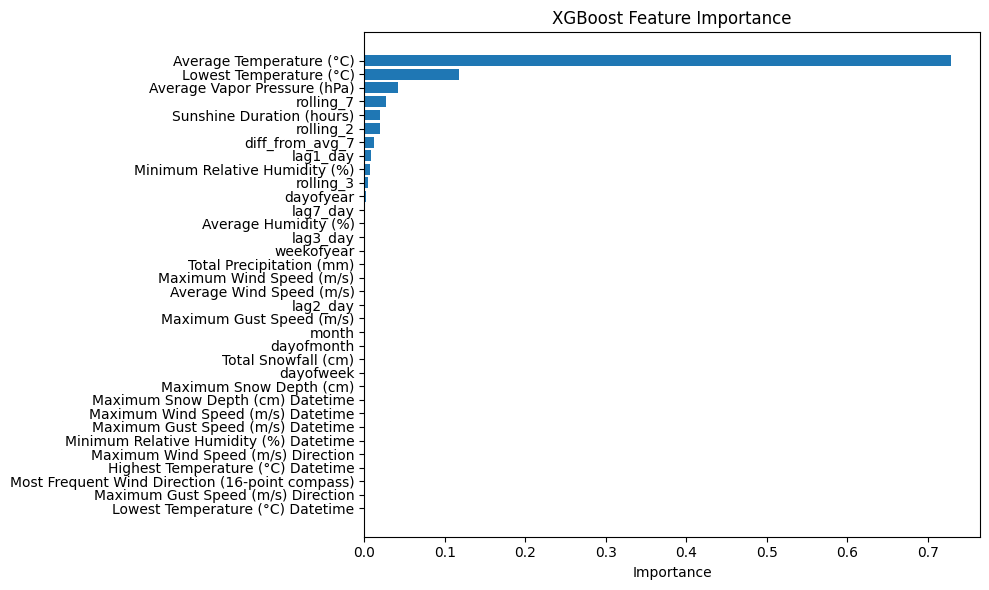

In [211]:
# Create comparison table
comparison_table = pd.DataFrame({
    "Date": test_df.index,
    "Actual": y_test.values,
    "Predicted": final_preds
})

# Error calculations
comparison_table["Error"] = comparison_table["Actual"] - comparison_table["Predicted"]
comparison_table["Absolute Error"] = comparison_table["Error"].abs()

# Absolute percentage error for MAPE
comparison_table["APE"] = np.abs(
    comparison_table["Error"] / comparison_table["Actual"]
)

# Remove infinity values caused by division by zero
comparison_table = comparison_table.replace([np.inf, -np.inf], np.nan)

# Convert APE to percentage
comparison_table["APE (%)"] = comparison_table["APE"] * 100

display(comparison_table)

# Final test errors
final_mae = mean_absolute_error(comparison_table["Actual"], comparison_table["Predicted"])
final_rmse = np.sqrt(mean_squared_error(comparison_table["Actual"], comparison_table["Predicted"]))
final_mape = comparison_table["APE"].dropna().mean() * 100

print("Final MAE:", final_mae)
print("Final RMSE:", final_rmse)
print("Final MAPE:", final_mape, "%")

feature_importance = pd.DataFrame({
    "Feature": FEATURES,
    "Importance": final_model.feature_importances_
}).sort_values("Importance", ascending=False)

display(feature_importance)

# Plot feature importance
plt.figure(figsize=(10, 6))
plt.barh(feature_importance["Feature"], feature_importance["Importance"])
plt.gca().invert_yaxis()
plt.title("XGBoost Feature Importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()